# Larsen C AWS data and RACMO (2km downscaled version)

Comparisons between AWS data and RACMO at our field site on Flask Glacier and at a site on the Larsen C Ice Shelf. 

Data from AWS18 on the Larsen C Ice Shelf comes from https://doi.pangaea.de/10.1594/PANGAEA.974128

Two other time series of temperature some from AWS20 (nearby) and were supplied to us in personal communication with Maurice van Tiggelen (m.vantiggelen@uu.nl).
These are the data in AWS20_temp.csv and AWS20_temp_2025.csv

Unlike code/aws/larsen_AWS_fieldseason.ipynb this NB loads the 2km downscaled version of RACMO (see code/rcm/racmo_2km_daily_1979-2025.ipynb).

In [46]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import hvplot.xarray
import matplotlib.pyplot as plt

In [2]:
FG_AWS = xr.load_dataset('aws_season_1.nc')  # created with code/aws/season_1.ipynb
FG_AWS

<xarray.Dataset> Size: 150kB
Dimensions:           (time: 335)
Coordinates:
    index             (time) int64 3kB 0 1 2 3 4 5 6 ... 329 330 331 332 333 334
  * time              (time) datetime64[ns] 3kB 2024-12-02T10:59:59.971000 .....
Data variables: (12/54)
    RECORD            (time) float64 3kB 6.0 7.0 8.0 9.0 ... 338.0 339.0 340.0
    TempVue20T_C_Avg  (time) float64 3kB -5.659 -6.46 -7.209 ... -4.144 -4.044
    TempVue20T_C_Max  (time) float64 3kB -5.26 -5.13 -6.92 ... -3.49 -3.79 -3.8
    TempVue20T_C_Min  (time) float64 3kB -5.99 -7.25 -7.39 ... -4.14 -4.49 -4.39
    AirTmpC_Avg       (time) float64 3kB -6.217 -6.929 -7.238 ... -4.166 -4.072
    AirTmpC_Max       (time) float64 3kB -6.031 -6.269 -7.1 ... -3.908 -3.866
    ...                ...
    GKN_9m_TmpC       (time) float64 3kB 7.915 9.23 9.59 ... -127.9 -127.9
    GKN_9_2m_TmpC     (time) float64 3kB 9.8 17.45 18.2 ... -127.9 -127.9 -127.9
    GKN_9_4m_TmpC     (time) float64 3kB 8.75 12.52 12.41 ... -127.9 -127.8
    GKN_9_6m_TmpC     (time) float64 3kB 8.53 13.71 14.9 ... -127.9 -127.9
    GKN_9_8m_TmpC     (time) float64 3kB 6.998 14.52 14.79 ... -127.9 -127.8
    GKN_10m_TmpC      (time) float64 3kB 6.675 12.85 12.91 ... -127.9 -127.8

## Load AWS18 data

In [3]:
fname = "../../data/flask/aws/AWS18/IMAU_ANT_AWS18.tab"

with open(fname) as f:
    lines = f.readlines()
# Find the first line that contains */
cut_line = next(i for i, line in enumerate(lines) if "*/" in line)
aws18_df = pd.read_csv("../../data/flask/aws/AWS18/IMAU_ANT_AWS18.tab", skiprows=cut_line+1, delimiter='\t', parse_dates=["Date/Time"] )  
# aws20_ds1 = aws18_df.set_index("Date/Time").to_xarray()
# aws20_ds1#['TTT [°C]']

## Load AWS20 data

In [ ]:
# load csvs into pandas dataframes
aws20_df1 = pd.read_csv("../../data/flask/aws/AWS20/AWS20_temp.csv", parse_dates=["datetime"] )  
aws20_df2 = pd.read_csv("../../data/flask/aws/AWS20/AWS20_temp_2025.csv", parse_dates=["datetime"] ) #This is using a slightly different sensor and has a little more recent data. Not significantly for this analysis though. 


## Combine all three AWS T time series 

In [16]:
# rename temperature columns
aws18_df = aws18_df.rename(columns={"TTT [°C]": "temperature"})
aws20_df1 = aws20_df1.rename(columns={"t": "temperature"})
aws20_df2 = aws20_df2.rename(columns={"Thut": "temperature"})

# rename datetime columns
aws18_df = aws18_df.rename(columns={"Date/Time": "datetime"})

# extract temperature data and convert to xarray datasets
def extract_temperature_ds(df): return df.set_index("datetime").to_xarray().temperature
aws18_ds = extract_temperature_ds(aws18_df)
aws20_ds1 = extract_temperature_ds(aws20_df1)
aws20_ds2 = extract_temperature_ds(aws20_df2)


aws20_ds2 = aws20_ds2.where(aws20_ds2 < 20)

AWS_LC = xr.merge([aws18_ds, aws20_ds1], compat="override")

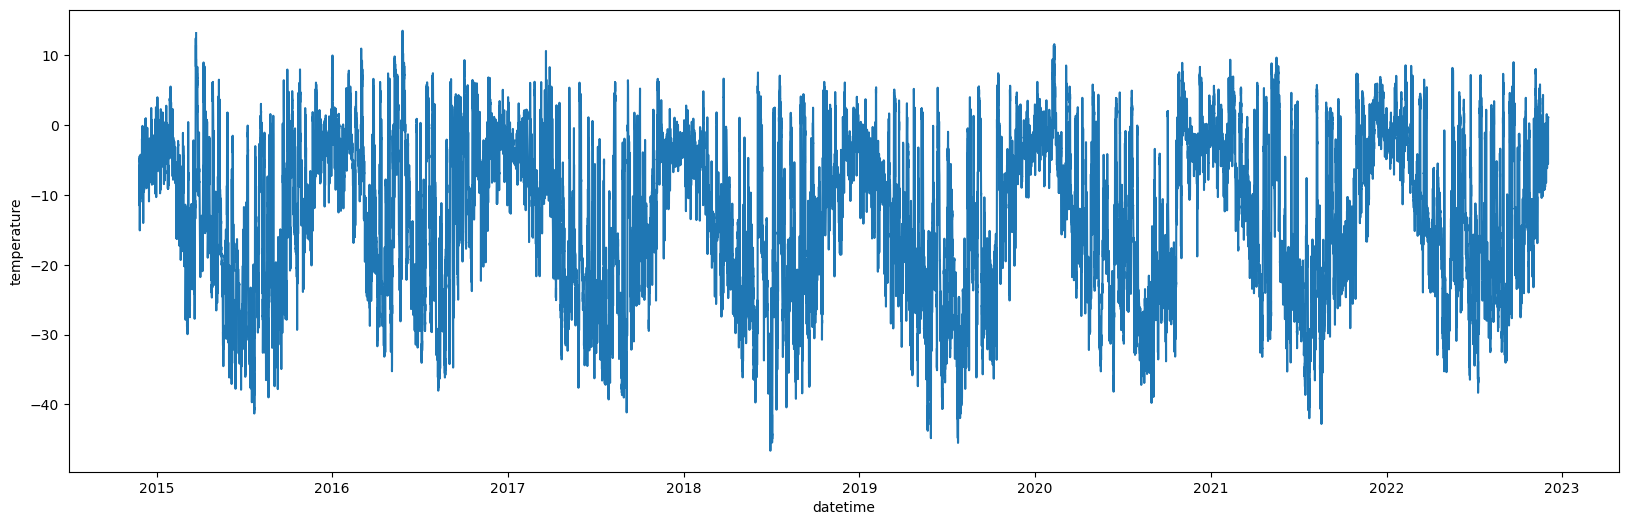

In [23]:
AWS_LC.temperature.plot(figsize=(20, 6))

## Compare to RACMO interpolated at the Larsen site

In [27]:
ds_wide = xr.open_dataset("../rcm/flask_wide_racmo2km.zarr", engine = 'zarr', chunks={})
ds_wide.load()

<xarray.Dataset> Size: 5GB
Dimensions:       (time: 17167, y: 111, x: 158)
Coordinates:
  * time          (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * x             (x) float32 632B -2.515e+06 -2.513e+06 ... -2.201e+06
  * y             (y) float32 444B 1.09e+06 1.092e+06 ... 1.308e+06 1.31e+06
Data variables:
    ff10mcorr     (time, y, x) float32 1GB nan nan nan nan ... 0.0 0.0 0.0 0.0
    precipcorr    (time, y, x) float32 1GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    snowmeltcorr  (time, y, x) float32 1GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    t2mcorr       (time, y, x) float32 1GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      Wed May 20 22:39:46 2026: cdo -f nc4 -z zip_5 copy ff10m/ff...
    institution:  IMAU (Brice Noel)
    netcdf:       4.9.0 of Jan  4 2023 16:53:07 $
    title:        Daily mean ff10m field at 2km (RACMO2.3p2 ANT27 ERA)

### AWS location

In [59]:
aws20_locations = gpd.read_file("../../data/flask/aws/larsen_AWS20_location.geojson")   # created by code/aws/larsen_AWS_fieldseason.ipynb
aws20_locations.to_crs(epsg=3031, inplace=True)
aws20_locations

,geometry
0,POINT (-2299145.99 1159921.946)


In [61]:
aws18_locations = gpd.read_file("../../data/flask/aws/larsen_AWS18_location.geojson")  # created by code/aws/larsen_AWS_fieldseason.ipynb
aws18_locations.to_crs(epsg=3031, inplace=True)

### Field site locations


In [73]:
field_site_locations = gpd.read_file("/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/fieldwork/recce_planning_oct25/site_names.shp")
field_site_locations.to_crs(epsg=3031, inplace=True)
flask_AWS_location = field_site_locations.iloc[[2]]
flask_AWS_location

,Site,Lat,Long,Elevation,geometry
2,Site 1,-65.793503,-62.677287,381,POINT (-2370653.103 1224775.687)


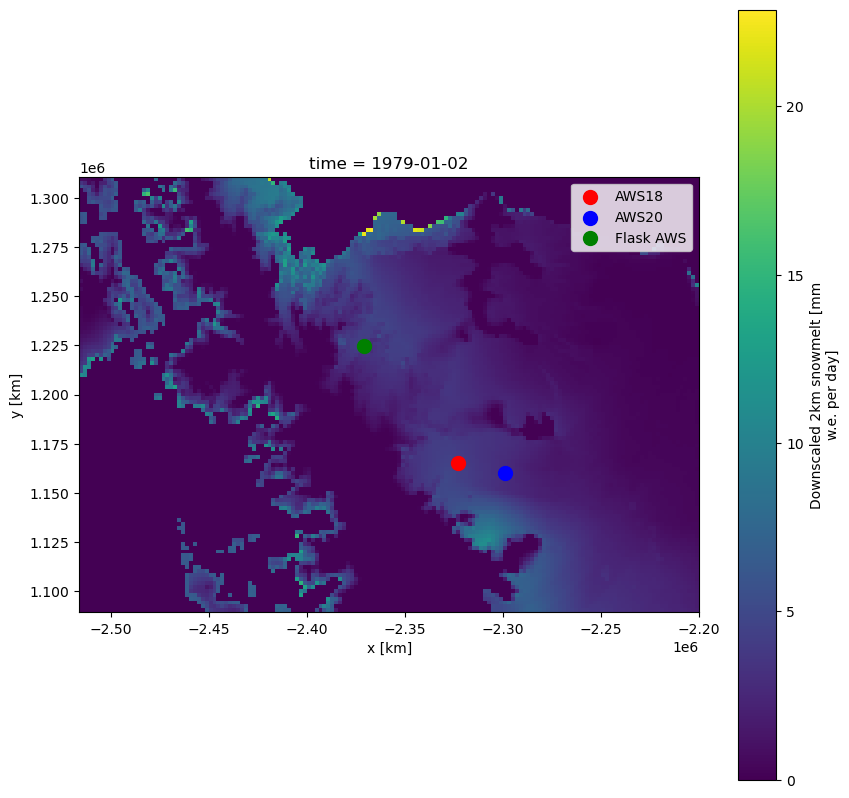

In [135]:
fig, ax = plt.subplots(figsize=(10, 10))
ds_wide.isel(time=1).snowmeltcorr.plot(ax=ax)
def add_dots(ax):
    aws18_locations.plot(ax=ax, label='AWS18', color='red', markersize=100)
    aws20_locations.plot(ax=ax, label='AWS20', color='blue', markersize=100)
    flask_AWS_location.plot(ax=ax, label='Flask AWS', color='green', markersize=100)
add_dots(ax)
plt.gca().set_aspect('equal') 
plt.legend()


In [287]:
racmo_at_aws18 = ds_wide.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
racmo_at_aws18_T = racmo_at_aws18.t2mcorr - 273.15
racmo_at_aws18_T = racmo_at_aws18_T.rename('AWS_18_t2m_racmo')
racmo_at_aws18_T.attrs['long_name'] = 'RACMO2km 2m air temperature at AWS18 location'
racmo_at_aws18_T.attrs['units'] = 'C'

racmo_at_aws20 = ds_wide.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
racmo_at_aws20_T = racmo_at_aws20.t2mcorr - 273.15
racmo_at_aws20_T = racmo_at_aws20_T.rename('AWS_20_t2m_racmo')
racmo_at_aws20_T.attrs['long_name'] = 'RACMO2km 2m air temperature at AWS20 location'
racmo_at_aws20_T.attrs['units'] = 'C'
  
racmo_at_flask_AWS = ds_wide.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
racmo_at_flask_AWS_T = racmo_at_flask_AWS.t2mcorr - 273.15
racmo_at_flask_AWS_T = racmo_at_flask_AWS_T.rename('Flask_AWS_t2m_racmo')
racmo_at_flask_AWS_T.attrs['long_name'] = 'RACMO2km 2m air temperature at Flask AWS location'
racmo_at_flask_AWS_T.attrs['units'] = 'C'

## Compare RACMO to itself at the locations of the three AWS sites

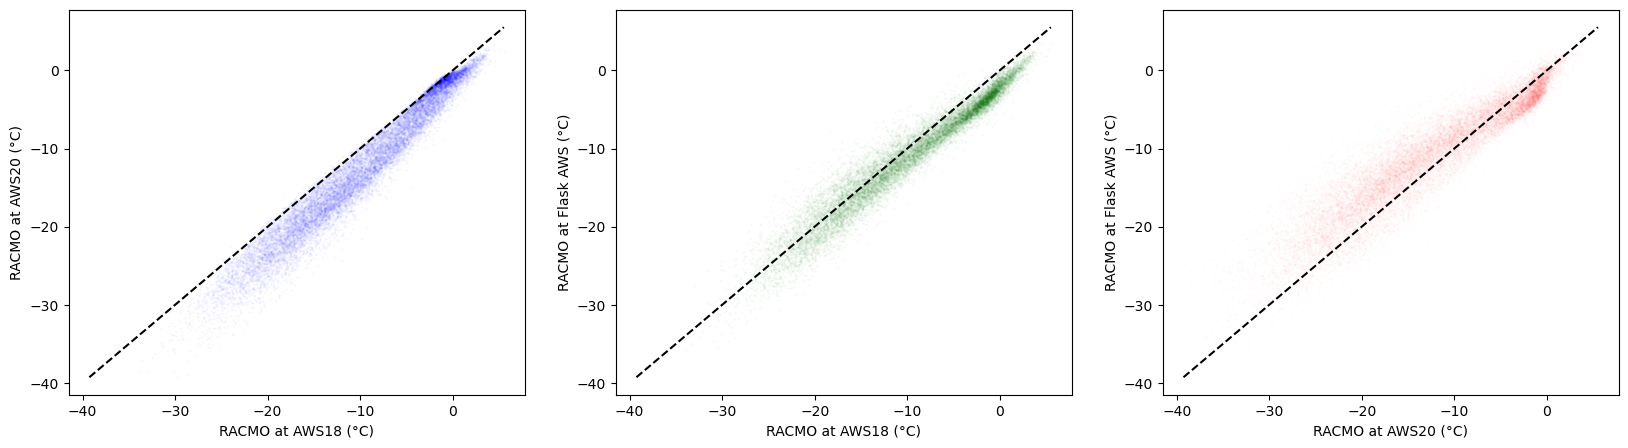

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].scatter(racmo_at_aws18_T, racmo_at_aws20_T, label='RACMO at AWS18 vs AWS20', color='blue', s=1, alpha=0.02)
axs[0].set_xlabel('RACMO at AWS18 (°C)')
axs[0].set_ylabel('RACMO at AWS20 (°C)')
min_temp = min(racmo_at_aws18_T.min().values, racmo_at_aws20_T.min().values)
max_temp = max(racmo_at_aws18_T.max().values, racmo_at_aws20_T.max().values)
axs[0].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')

axs[1].scatter(racmo_at_aws18_T, racmo_at_flask_AWS_T, label='RACMO at AWS18 vs Flask AWS', color='green', s=1, alpha=0.02)
axs[1].set_xlabel('RACMO at AWS18 (°C)')
axs[1].set_ylabel('RACMO at Flask AWS (°C)')
axs[1].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')

axs[2].scatter(racmo_at_aws20_T, racmo_at_flask_AWS_T, label='RACMO at AWS20 vs Flask AWS', color='red', s=1, alpha=0.01)
axs[2].set_xlabel('RACMO at AWS20 (°C)')
axs[2].set_ylabel('RACMO at Flask AWS (°C)')
axs[2].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')

In [ ]:
corr_18=xr.corr(racmo_at_aws18_T, ds_wide.t2mcorr, dim='time')
corr_20=xr.corr(racmo_at_aws20_T, ds_wide.t2mcorr, dim='time')
corr_flask=xr.corr(racmo_at_flask_AWS_T, ds_wide.t2mcorr, dim='time')

Text(0.5, 0.98, 'Spatial correlation of RACMO2km 2m, all year')

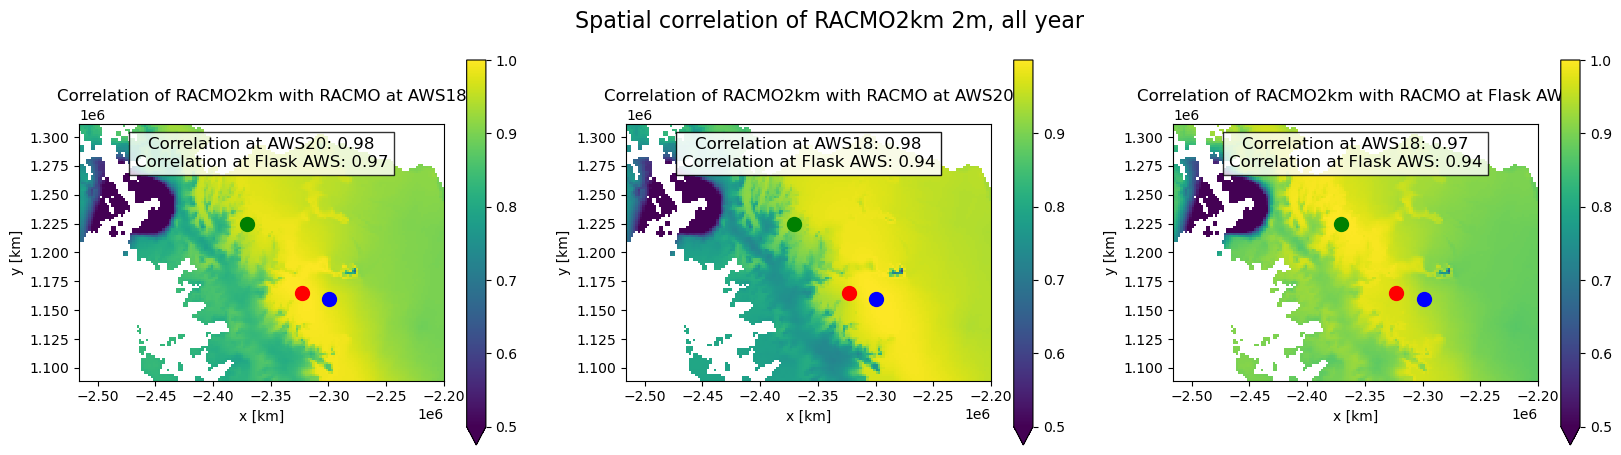

In [160]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
corr_18.plot(ax=axs[0], vmin=0.5)
axs[0].set_title('Correlation of RACMO2km with RACMO at AWS18')
add_dots(axs[0])
corr_at_20 = corr_18.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_18.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[0].text(0.5, 0.95, f'Correlation at AWS20: {corr_at_20.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[0].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

corr_20.plot(ax=axs[1], vmin=0.5)
axs[1].set_title('Correlation of RACMO2km with RACMO at AWS20')
add_dots(axs[1])
corr_at_18 = corr_20.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_20.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[1].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[1].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.9))

corr_flask.plot(ax=axs[2], vmin=0.5)
axs[2].set_title('Correlation of RACMO2km with RACMO at Flask AWS')
add_dots(axs[2])
corr_at_18 = corr_flask.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_20 = corr_flask.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
axs[2].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_20.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[2].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

fig.suptitle('Spatial correlation of RACMO2km 2m, all year', fontsize=16)


In [275]:
summer_month_numbers = [11, 12, 1, 2]
winter_month_numbers = [3, 4, 5, 6, 7, 8, 9, 10]
ds_wide_sum = ds_wide.where(ds_wide.time.dt.month.isin(summer_month_numbers), drop=True)
ds_wide_winter = ds_wide.where(ds_wide.time.dt.month.isin(winter_month_numbers), drop=True)


In [285]:
# summer

racmo_at_aws18_sum_T = ds_wide_sum.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest').t2mcorr - 273.15
racmo_at_aws20_sum_T = ds_wide_sum.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest').t2mcorr - 273.15
racmo_at_flask_sum_T = ds_wide_sum.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest').t2mcorr - 273.15

corr_18_sum=xr.corr(racmo_at_aws18_sum_T, ds_wide_sum.t2mcorr, dim='time')
corr_20_sum=xr.corr(racmo_at_aws20_sum_T, ds_wide_sum.t2mcorr, dim='time')
corr_flask_sum=xr.corr(racmo_at_flask_sum_T, ds_wide_sum.t2mcorr, dim='time')

# winter
racmo_at_aws18_winter_T = ds_wide_winter.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest').t2mcorr - 273.15
racmo_at_aws20_winter_T = ds_wide_winter.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest').t2mcorr - 273.15
racmo_at_flask_winter_T = ds_wide_winter.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest').t2mcorr - 273.15


corr_18_winter=xr.corr(racmo_at_aws18_winter_T, ds_wide_winter.t2mcorr, dim='time')
corr_20_winter=xr.corr(racmo_at_aws20_winter_T, ds_wide_winter.t2mcorr, dim='time')
corr_flask_winter=xr.corr(racmo_at_flask_winter_T, ds_wide_winter.t2mcorr, dim='time')

KeyboardInterrupt: 

In [282]:
corr_flask_winter

<xarray.DataArray 't2mcorr' (y: 111, x: 158)> Size: 70kB
array([[       nan,        nan,        nan, ..., 0.7716551 , 0.7710367 ,
        0.7714784 ],
       [       nan,        nan,        nan, ..., 0.774121  , 0.77189654,
        0.7727964 ],
       [       nan,        nan,        nan, ..., 0.7751178 , 0.7720278 ,
        0.77318037],
       ...,
       [0.851944  , 0.85335976, 0.8524522 , ...,        nan,        nan,
               nan],
       [0.8582115 , 0.8576986 , 0.85060936, ...,        nan,        nan,
               nan],
       [0.85585856, 0.8576467 , 0.8572236 , ...,        nan,        nan,
               nan]], shape=(111, 158), dtype=float32)
Coordinates:
  * x        (x) float32 632B -2.515e+06 -2.513e+06 ... -2.203e+06 -2.201e+06
  * y        (y) float32 444B 1.09e+06 1.092e+06 ... 1.308e+06 1.31e+06

Text(0.5, 0.98, 'Spatial correlation of RACMO2km 2m, just Nov-Feb')

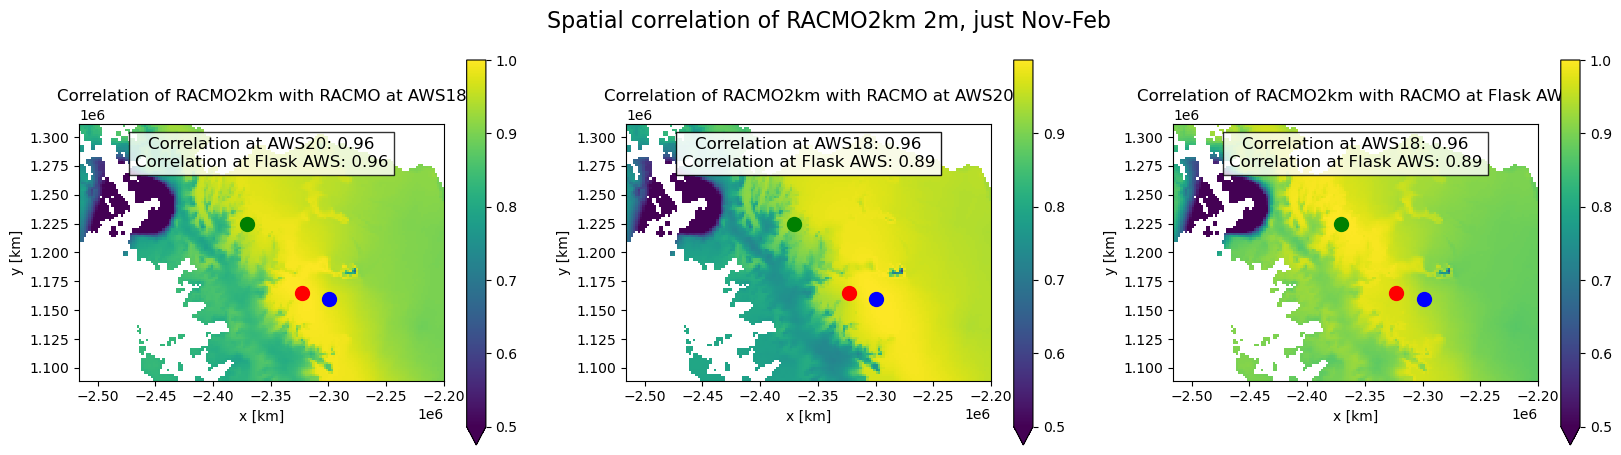

In [283]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
corr_18.plot(ax=axs[0], vmin=0.5)
axs[0].set_title('Correlation of RACMO2km with RACMO at AWS18')
add_dots(axs[0])
corr_at_20 = corr_18_sum.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_18_sum.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[0].text(0.5, 0.95, f'Correlation at AWS20: {corr_at_20.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[0].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

corr_20.plot(ax=axs[1], vmin=0.5)
axs[1].set_title('Correlation of RACMO2km with RACMO at AWS20')
add_dots(axs[1])
corr_at_18 = corr_20_sum.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_20_sum.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[1].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[1].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.9))

corr_flask.plot(ax=axs[2], vmin=0.5)
axs[2].set_title('Correlation of RACMO2km with RACMO at Flask AWS')
add_dots(axs[2])
corr_at_18 = corr_flask_sum.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_20 = corr_flask_sum.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
axs[2].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_20.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[2].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

fig.suptitle('Spatial correlation of RACMO2km 2m, just Nov-Feb', fontsize=16)


Text(0.5, 0.98, 'Spatial correlation of RACMO2km 2m, just Mar-Nov')

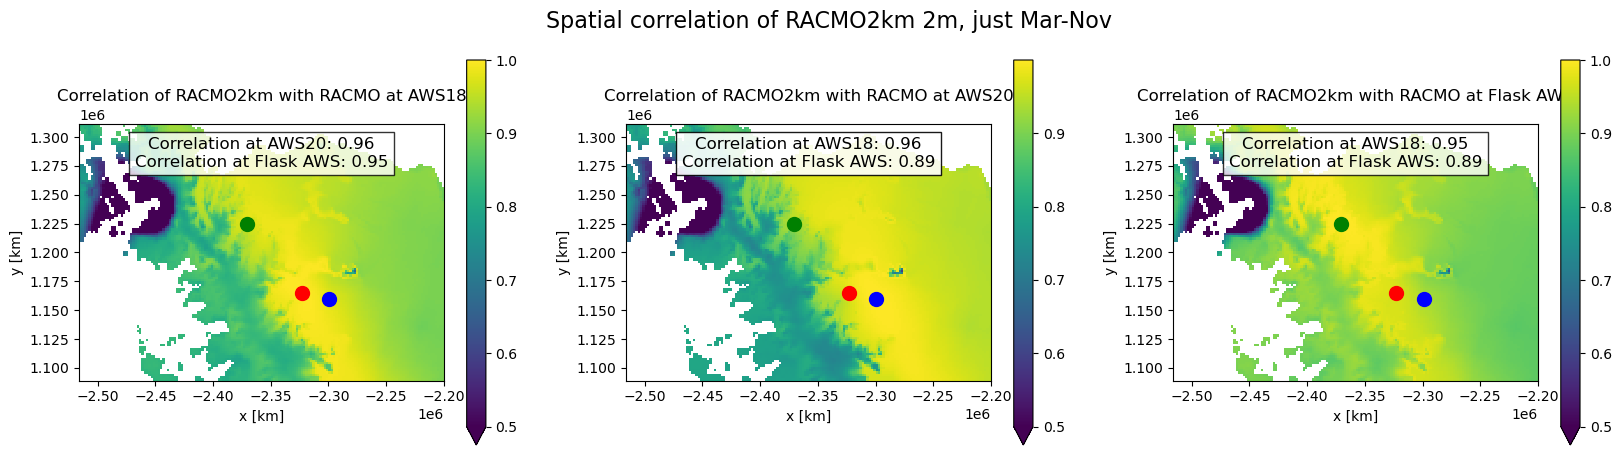

In [284]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
corr_18.plot(ax=axs[0], vmin=0.5)
axs[0].set_title('Correlation of RACMO2km with RACMO at AWS18')
add_dots(axs[0])
corr_at_20 = corr_18_winter.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_18_winter.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[0].text(0.5, 0.95, f'Correlation at AWS20: {corr_at_20.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[0].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

corr_20.plot(ax=axs[1], vmin=0.5)
axs[1].set_title('Correlation of RACMO2km with RACMO at AWS20')
add_dots(axs[1])
corr_at_18 = corr_20_winter.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_20_winter.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[1].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[1].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.9))

corr_flask.plot(ax=axs[2], vmin=0.5)
axs[2].set_title('Correlation of RACMO2km with RACMO at Flask AWS')
add_dots(axs[2])
corr_at_18 = corr_flask_winter.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_20 = corr_flask_winter.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
axs[2].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_20.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[2].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

fig.suptitle('Spatial correlation of RACMO2km 2m, just Mar-Nov', fontsize=16)


## Accumulation and melt

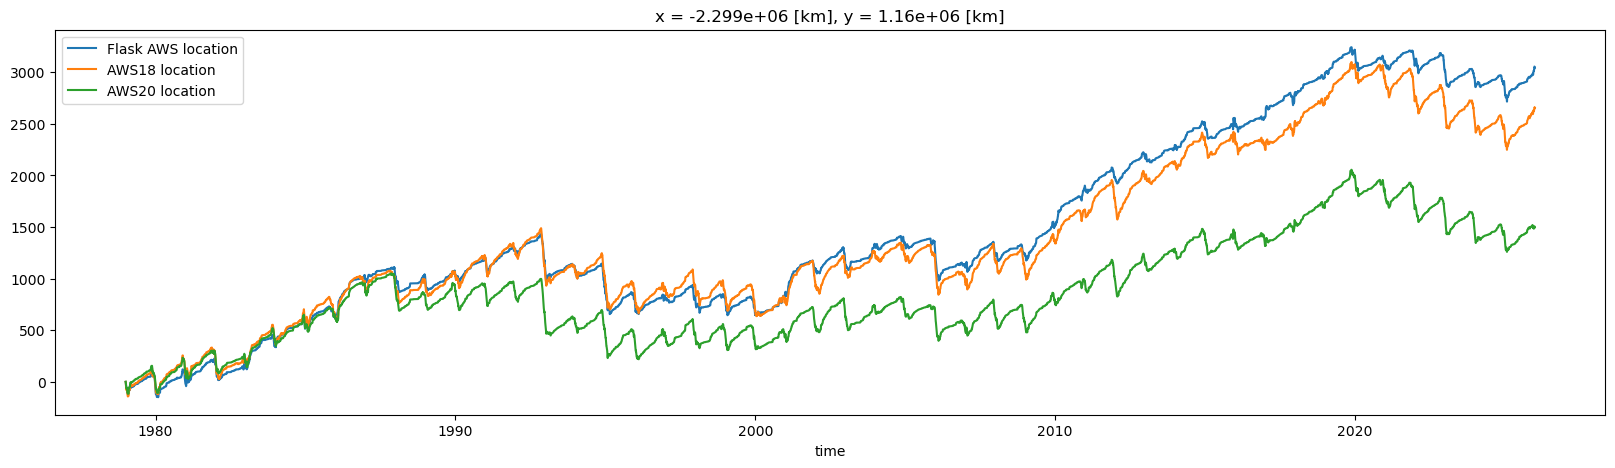

In [301]:
fig, axs = plt.subplots(1, 1, figsize=(20, 5))

m_flask = racmo_at_flask_AWS.snowmeltcorr
m_flask_c = m_flask.cumsum(dim='time').rename('cumulative_snowmelt')
m_flask_c.attrs['long_name'] = 'Cumulative snowmelt at Flask AWS location'
m_flask_c.attrs['units'] = 'mm'

p_flask = racmo_at_flask_AWS.precipcorr
p_flask_c = p_flask.cumsum(dim='time').rename('cumulative_precipitation')
p_flask_c.attrs['long_name'] = 'Cumulative precipitation at Flask AWS location'
p_flask_c.attrs['units'] = 'mm'

(p_flask_c - m_flask_c).plot(ax=axs, label='Flask AWS location')

m_18 = racmo_at_aws18.snowmeltcorr
m_18_c = m_18.cumsum(dim='time').rename('cumulative_snowmelt')
m_18_c.attrs['long_name'] = 'Cumulative snowmelt at AWS18 location'
m_18_c.attrs['units'] = 'mm'

p_18 = racmo_at_aws18.precipcorr
p_18_c = p_18.cumsum(dim='time').rename('cumulative_precipitation')
p_18_c.attrs['long_name'] = 'Cumulative precipitation at AWS18 location'
p_18_c.attrs['units'] = 'mm'

(p_18_c - m_18_c).plot(ax=axs, label='AWS18 location')

m_20 = racmo_at_aws20.snowmeltcorr
m_20_c = m_20.cumsum(dim='time').rename('cumulative_snowmelt')
m_20_c.attrs['long_name'] = 'Cumulative snowmelt at AWS20 location'
m_20_c.attrs['units'] = 'mm'

p_20 = racmo_at_aws20.precipcorr
p_20_c = p_20.cumsum(dim='time').rename('cumulative_precipitation')
p_20_c.attrs['long_name'] = 'Cumulative precipitation at AWS20 location'
p_20_c.attrs['units'] = 'mm'

(p_20_c - m_20_c).plot(ax=axs,  label='AWS20 location')


# m_mean = ds_wide.mean(dim=['x', 'y']).snowmeltcorr
# m_mean_c = m_mean.cumsum(dim='time').rename('cumulative_snowmelt')
# m_mean_c.attrs['long_name'] = 'Cumulative snowmelt at mean location'
# m_mean_c.attrs['units'] = 'mm'

# p_mean = ds_wide.mean(dim=['x', 'y']).precipcorr
# p_mean_c = p_mean.cumsum(dim='time').rename('cumulative_precipitation')
# p_mean_c.attrs['long_name'] = 'Cumulative precipitation at mean location'
# p_mean_c.attrs['units'] = 'mm'

# (p_mean_c - m_mean_c).plot(ax=axs,  label='Mean over subset')


plt.legend()

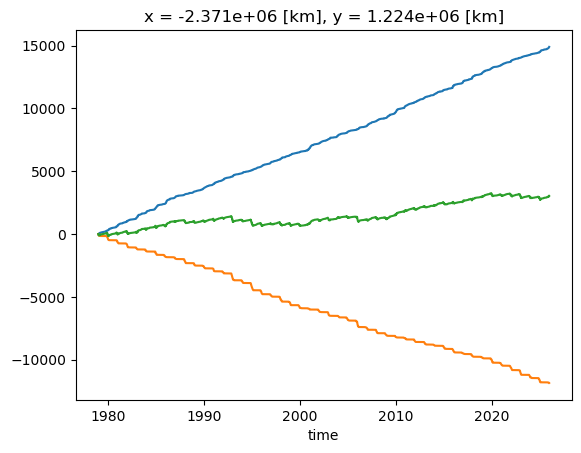

In [304]:
p_flask_c.plot()
(-m_flask_c).plot()
(p_flask_c - m_flask_c).plot()


## Compare RACMO and the AWS data

Text(0.5, 1.0, 'AWS18 vs RACMO2km 2m air temperature')

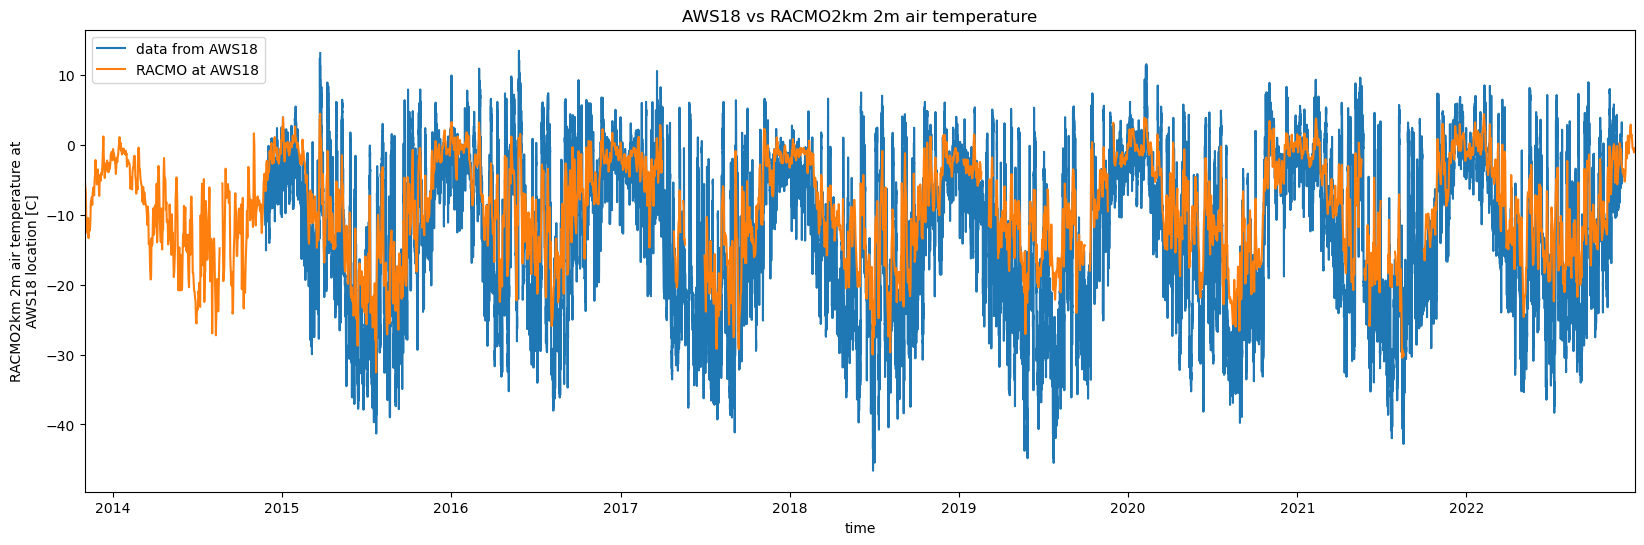

In [ ]:
aws18_ds.plot(label='data from AWS18', figsize=(20, 6))
racmo_at_aws18_T.plot(xlim=(pd.Timestamp('2013-11-01'), pd.Timestamp('2022-12-31')),  label='RACMO at AWS18')
plt.legend()
plt.title('AWS18 vs RACMO2km 2m air temperature')

Text(0.5, 1.0, 'AWS20 vs RACMO2km 2m air temperature')

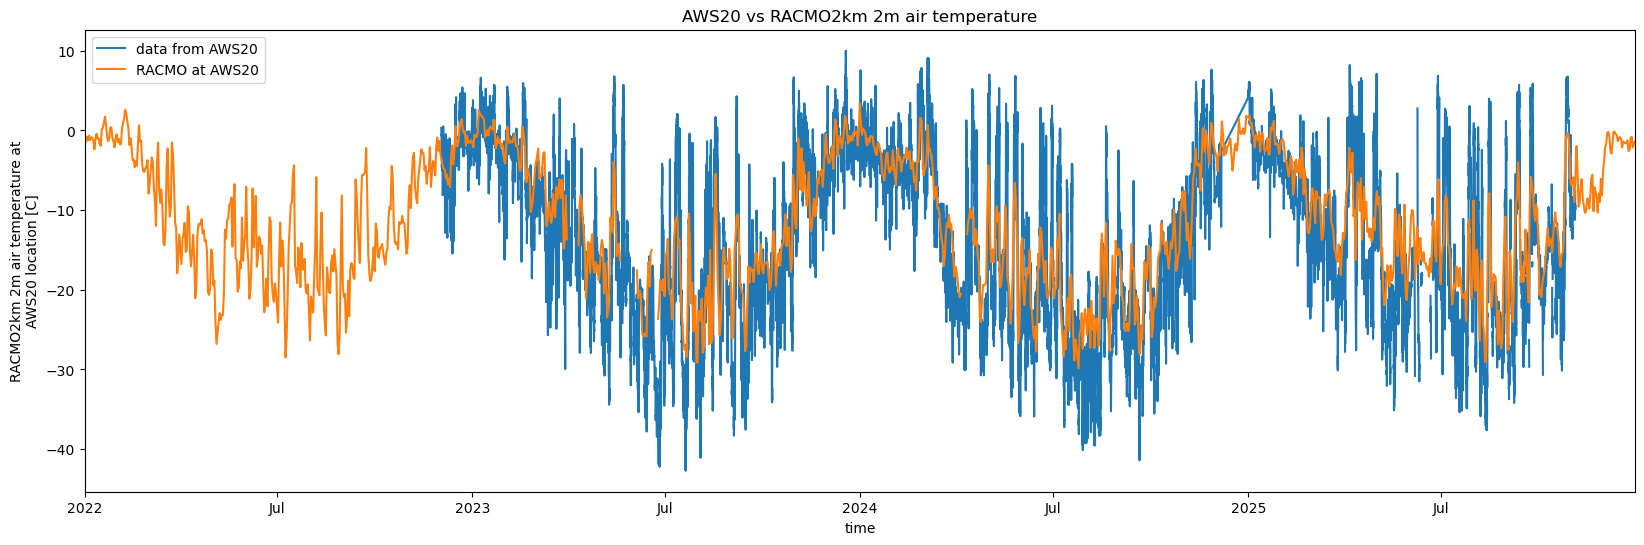

In [ ]:
aws20_ds1.plot(label='data from AWS20', figsize=(20, 6))
racmo_at_aws20_T.plot(xlim=(pd.Timestamp('2022-01-01'), pd.Timestamp('2025-12-31')),  label='RACMO at AWS20')
plt.legend()
plt.title('AWS20 vs RACMO2km 2m air temperature')

Text(0.5, 1.0, 'Flask AWS vs RACMO2km 2m air temperature')

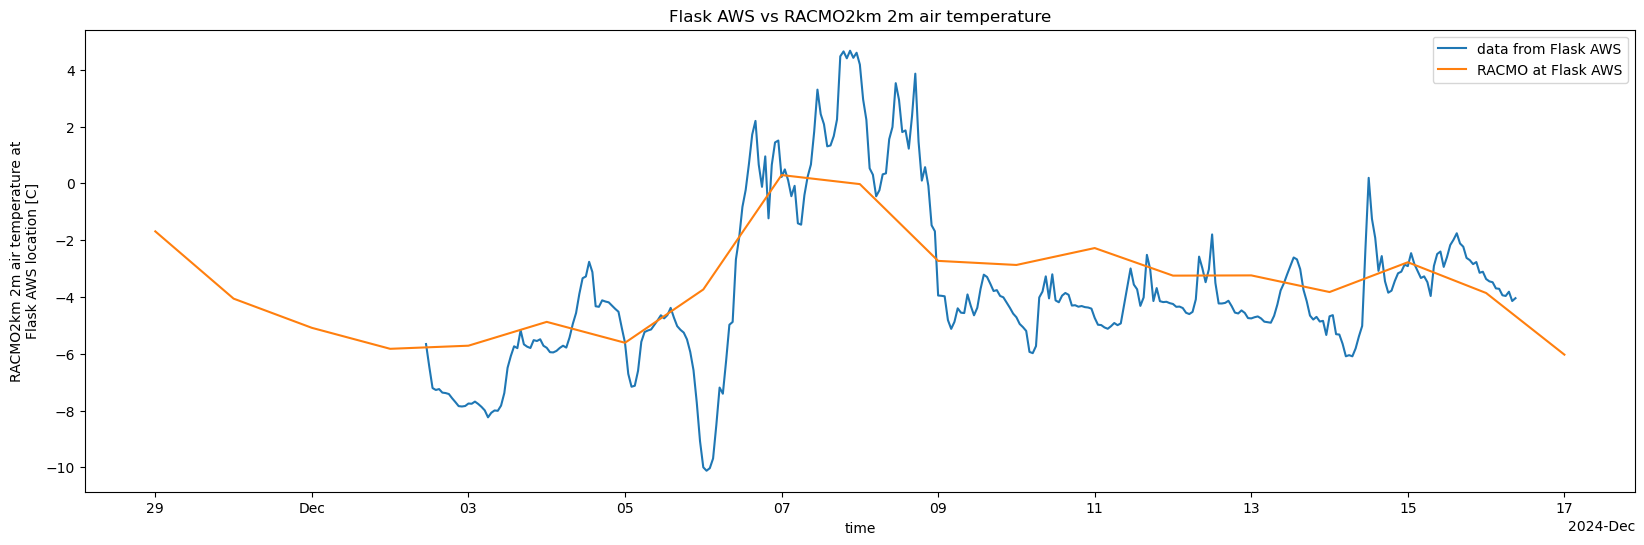

In [ ]:
FG_AWS = xr.load_dataset('aws_season_1.nc')
FG_AWS.TempVue20T_C_Avg.plot(label='data from Flask AWS', figsize=(20, 6))
racmo_at_flask_AWS_T.sel(time=slice(pd.Timestamp('2024-11-29'), pd.Timestamp('2024-12-17'))).plot(label='RACMO at Flask AWS')
plt.legend()
plt.title('Flask AWS vs RACMO2km 2m air temperature')

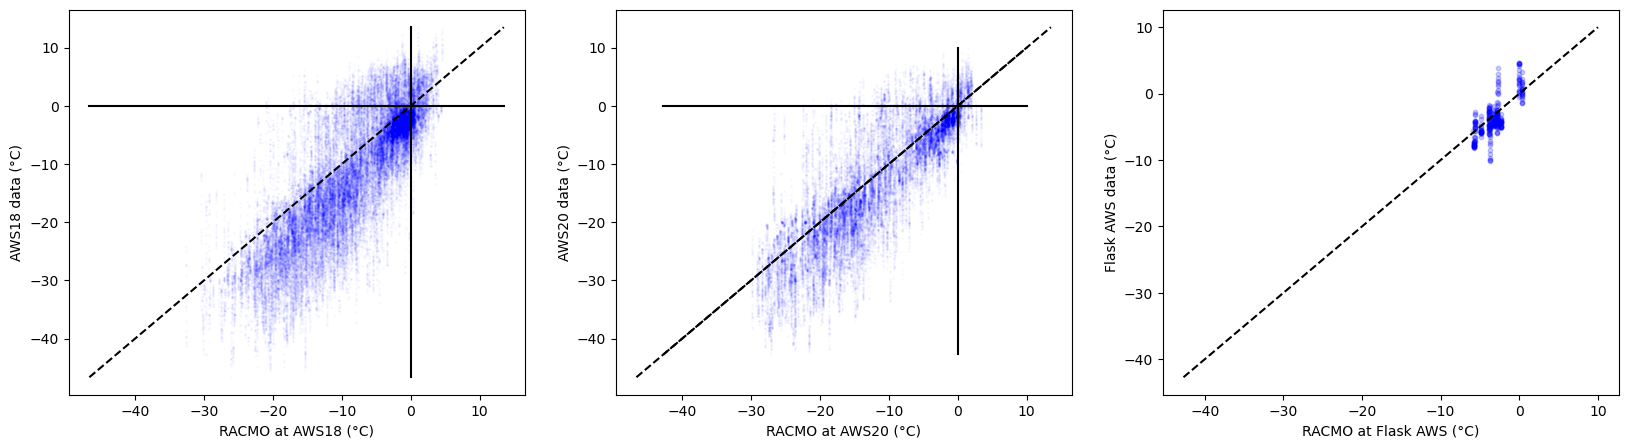

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

racmo_at_aws18_time_intered = racmo_at_aws18_T.sel(time=aws18_ds.datetime, method='nearest')

axs[0].scatter(racmo_at_aws18_time_intered, 
               aws18_ds,  
               color='blue', s=1, alpha=0.02)
axs[0].set_xlabel('RACMO at AWS18 (°C)')
axs[0].set_ylabel('AWS18 data (°C)')

min_temp, max_temp = min(aws18_ds.min().values, aws18_ds.min().values), max(aws18_ds.max().values, aws18_ds.max().values)
axs[0].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')
axs[0].plot([0, 0], [min_temp, max_temp], color='black', linestyle='-')
axs[0].plot([min_temp, max_temp], [0, 0], color='black', linestyle='-')

racmo_at_aws20_time_intered = racmo_at_aws20_T.sel(time=aws20_ds1.datetime, method='nearest')

axs[1].scatter(racmo_at_aws20_time_intered, 
               aws20_ds1, 
               color='blue', s=1, alpha=0.02)
axs[1].set_xlabel('RACMO at AWS20 (°C)')
axs[1].set_ylabel('AWS20 data (°C)')
axs[1].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')

min_temp, max_temp = min(aws20_ds1.min().values, aws20_ds1.min().values), max(aws20_ds1.max().values, aws20_ds1.max().values)
axs[1].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')
axs[1].plot([0, 0], [min_temp, max_temp], color='black', linestyle='-')
axs[1].plot([min_temp, max_temp], [0, 0], color='black', linestyle='-')

racmo_at_flask_AWS_time_intered = racmo_at_flask_AWS_time_intered = racmo_at_flask_AWS_T.sel(time=FG_AWS.TempVue20T_C_Avg.time, method='nearest')

axs[2].scatter(racmo_at_flask_AWS_time_intered, FG_AWS.TempVue20T_C_Avg, color='blue', s=10, alpha=0.2)
axs[2].set_xlabel('RACMO at Flask AWS (°C)')
axs[2].set_ylabel('Flask AWS data (°C)')
axs[2].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')


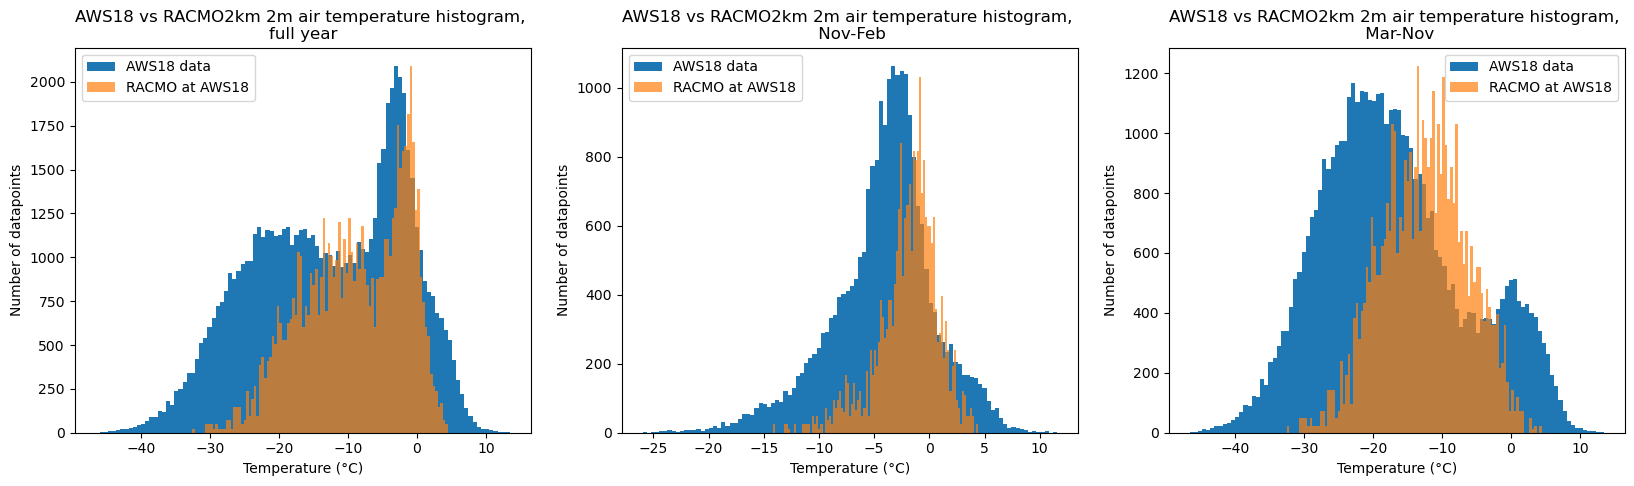

In [ ]:

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

aws18_ds.plot.hist(bins=100,  label='AWS18 data', ax=axs[0]);
racmo_at_aws18_time_intered.plot.hist( bins=100, alpha=0.7, label='RACMO at AWS18', ax=axs[0]);
axs[0].set_ylabel('Number of datapoints')
axs[0].set_xlabel('Temperature (°C)')
axs[0].set_title('AWS18 vs RACMO2km 2m air temperature histogram, \nfull year')
axs[0].legend()


aws18_ds.where(aws18_ds.datetime.dt.month.isin(summer_month_numbers), drop=True).plot.hist(bins=100,  label='AWS18 data', ax=axs[1]);
racmo_at_aws18_time_intered.where(racmo_at_aws18_time_intered.datetime.dt.month.isin(summer_month_numbers), drop=True).plot.hist( bins=100, alpha=0.7, label='RACMO at AWS18', ax=axs[1]);
axs[1].set_ylabel('Number of datapoints')
axs[1].set_xlabel('Temperature (°C)')
axs[1].set_title('AWS18 vs RACMO2km 2m air temperature histogram, \n Nov-Feb')
axs[1].legend()

aws18_ds.where(aws18_ds.datetime.dt.month.isin(winter_month_numbers), drop=True).plot.hist(bins=100,  label='AWS18 data', ax=axs[2]);
racmo_at_aws18_time_intered.where(racmo_at_aws18_time_intered.datetime.dt.month.isin(winter_month_numbers), drop=True).plot.hist( bins=100, alpha=0.7, label='RACMO at AWS18', ax=axs[2]);
axs[2].set_ylabel('Number of datapoints')
axs[2].set_xlabel('Temperature (°C)')
axs[2].set_title('AWS18 vs RACMO2km 2m air temperature histogram, \n Mar-Nov')
axs[2].legend()

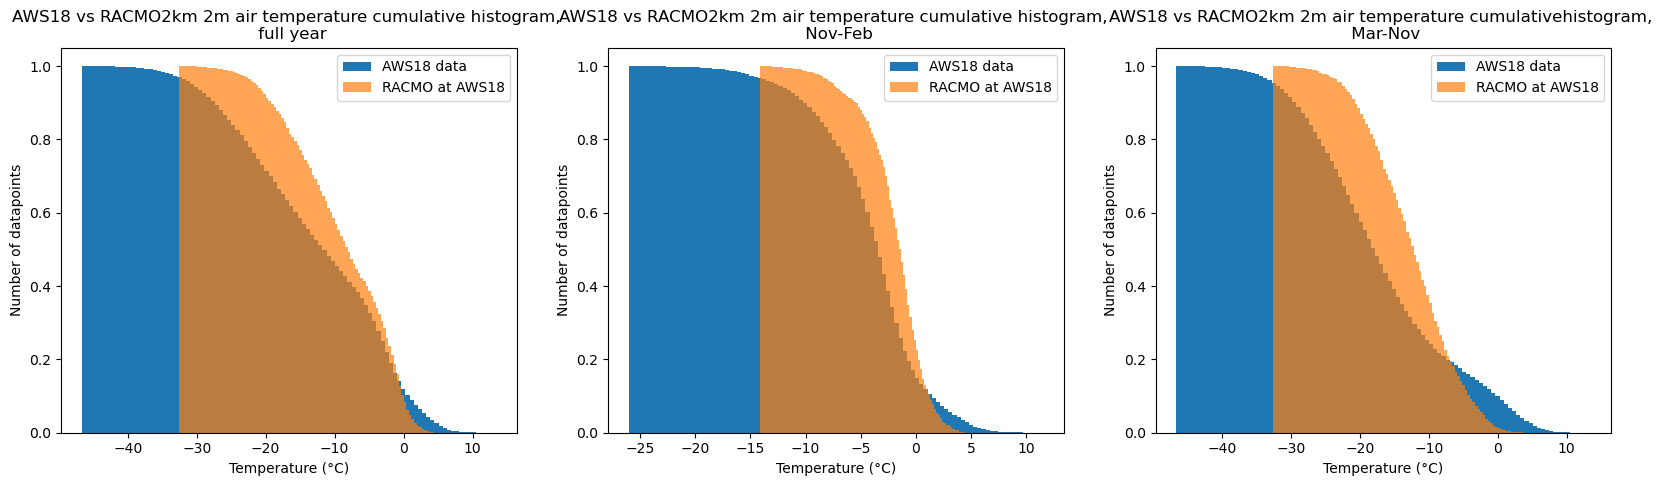

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

aws18_ds.plot.hist(cumulative=-1, bins=100, density=True, label='AWS18 data', ax=axs[0]);
racmo_at_aws18_time_intered.plot.hist(cumulative=-1, bins=100, density=True, alpha=0.7, label='RACMO at AWS18', ax=axs[0]);
axs[0].set_ylabel('Number of datapoints')
axs[0].set_xlabel('Temperature (°C)')
axs[0].set_title('AWS18 vs RACMO2km 2m air temperature cumulative histogram, \n full year')
axs[0].legend()


aws18_ds.where(aws18_ds.datetime.dt.month.isin(summer_month_numbers), drop=True).plot.hist(cumulative=-1, bins=100, density=True, label='AWS18 data', ax=axs[1]);
racmo_at_aws18_time_intered.where(racmo_at_aws18_time_intered.datetime.dt.month.isin(summer_month_numbers), drop=True).plot.hist( cumulative=-1, bins=100, density=True, alpha=0.7, label='RACMO at AWS18', ax=axs[1]);
axs[1].set_ylabel('Number of datapoints')
axs[1].set_xlabel('Temperature (°C)')
axs[1].set_title('AWS18 vs RACMO2km 2m air temperature cumulative histogram, \n Nov-Feb')
axs[1].legend()

aws18_ds.where(aws18_ds.datetime.dt.month.isin(winter_month_numbers), drop=True).plot.hist(cumulative=-1, bins=100, density=True, label='AWS18 data', ax=axs[2]);
racmo_at_aws18_time_intered.where(racmo_at_aws18_time_intered.datetime.dt.month.isin(winter_month_numbers), drop=True).plot.hist( cumulative=-1, bins=100, density=True, alpha=0.7, label='RACMO at AWS18', ax=axs[2]);
axs[2].set_ylabel('Number of datapoints')
axs[2].set_xlabel('Temperature (°C)')
axs[2].set_title('AWS18 vs RACMO2km 2m air temperature cumulative histogram, \n Mar-Nov')
axs[2].legend()



In [ ]:

ds_annual = ds.sel(time=slice('1979-01-01', '2025-06-30')).resample(time='YS-JUL').sum('time').mean(['x', 'y'])
ds_annual['time'] = ds_annual.indexes['time'].shift(1, freq='YS')
